In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import fasttext
import fasttext.util

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
max_words = 5000
max_len = 10

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data[text_column])
X = tokenizer.texts_to_sequences(data[text_column])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

y = data[target_column]

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train FastText model
# Prepare text file for FastText
fasttext_input_path = 'fasttext_input.txt'
data[text_column].to_csv(fasttext_input_path, index=False, header=False)

# Train the FastText model
ft_model = fasttext.train_unsupervised(fasttext_input_path, model='skipgram', dim=100)

# Step 4: Prepare FastText embedding matrix
embedding_dim = 100
embedding_matrix = np.zeros((max_words, embedding_dim))

# Populate the embedding matrix with FastText vectors
for word, index in tokenizer.word_index.items():
    if index < max_words:
        embedding_vector = ft_model.get_word_vector(word)
        embedding_matrix[index] = embedding_vector

# Step 5: Build the BiLSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len, weights=[embedding_matrix], trainable=False),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the BiLSTM model
print("Training BiLSTM Model with FastText Embeddings...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Step 7: Evaluate the BiLSTM model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"BiLSTM Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Save the trained BiLSTM model
model_path = r"C:\Users\PC\Downloads\BiLSTM_fasttext_model.h5"
model.save(model_path)
print(f"Trained BiLSTM model saved to {model_path}")

# Step 9: Make predictions and calculate additional metrics
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Step 10: Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Training BiLSTM Model with FastText Embeddings...
Epoch 1/20


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


4641/4641 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.8705 - loss: 0.3085 - val_accuracy: 0.9102 - val_loss: 0.2239
Epoch 2/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step - accuracy: 0.9055 - loss: 0.2313 - val_accuracy: 0.9149 - val_loss: 0.2086
Epoch 3/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step - accuracy: 0.9122 - loss: 0.2159 - val_accuracy: 0.9189 - val_loss: 0.2029
Epoch 4/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9157 - loss: 0.2074 - val_accuracy: 0.9195 - val_loss: 0.1981
Epoch 5/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9181 - loss: 0.2005 - val_accuracy: 0.9205 - val_loss: 0.1970
Epoch 6/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9215 - loss: 0.1940 - val_accuracy: 0.9181 - val_loss: 0.1965
Epoch 7/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - accuracy: 0.9253 - loss: 0.1859 - val_accuracy: 0.9207 - val_loss: 0.1944
Epoch 8/20
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9265 - loss: 0.1822 - val

BiLSTM Test Accuracy: 92.08%
Trained BiLSTM model saved to C:\Users\PC\Downloads\BiLSTM_fasttext_model.h5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Accuracy: 92.08%
Precision: 92.95%
Recall: 91.04%
F1 Score: 91.99%
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     23238
           1       0.93      0.91      0.92     23171

    accuracy                           0.92     46409
   macro avg       0.92      0.92      0.92     46409
weighted avg       0.92      0.92      0.92     46409



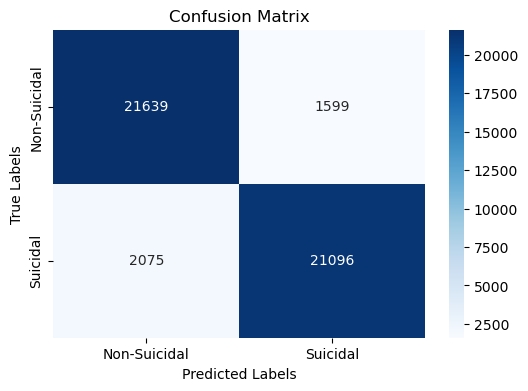

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Suicidal', 'Suicidal'], yticklabels=['Non-Suicidal', 'Suicidal'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


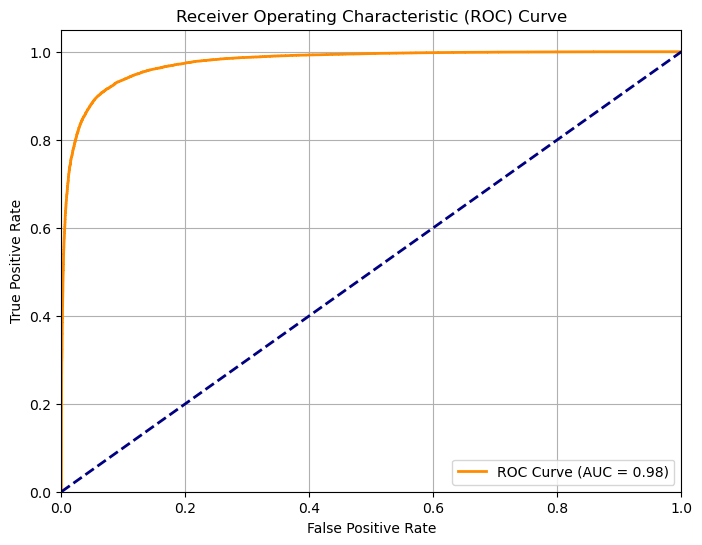

In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities instead of binary outputs
y_probs = model.predict(X_test)

# Calculate False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Mean Absolute Error (MAE): 0.0989
Mean Squared Error (MSE): 0.0599
Root Mean Squared Error (RMSE): 0.2447


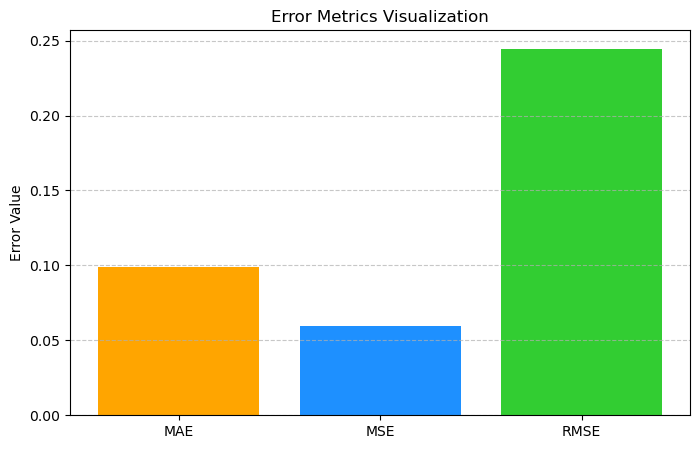

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Predict probabilities
y_probs = model.predict(X_test)

# Calculate MAE, MSE, and RMSE
mae = mean_absolute_error(y_test, y_probs)
mse = mean_squared_error(y_test, y_probs)
rmse = np.sqrt(mse)

# Display the metrics
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Visualization with orange, blue, green
metrics = ['MAE', 'MSE', 'RMSE']
values = [mae, mse, rmse]
colors = ['#FFA500', '#1E90FF', '#32CD32']  # Orange, Blue, Green

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=colors)
plt.title('Error Metrics Visualization')
plt.ylabel('Error Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


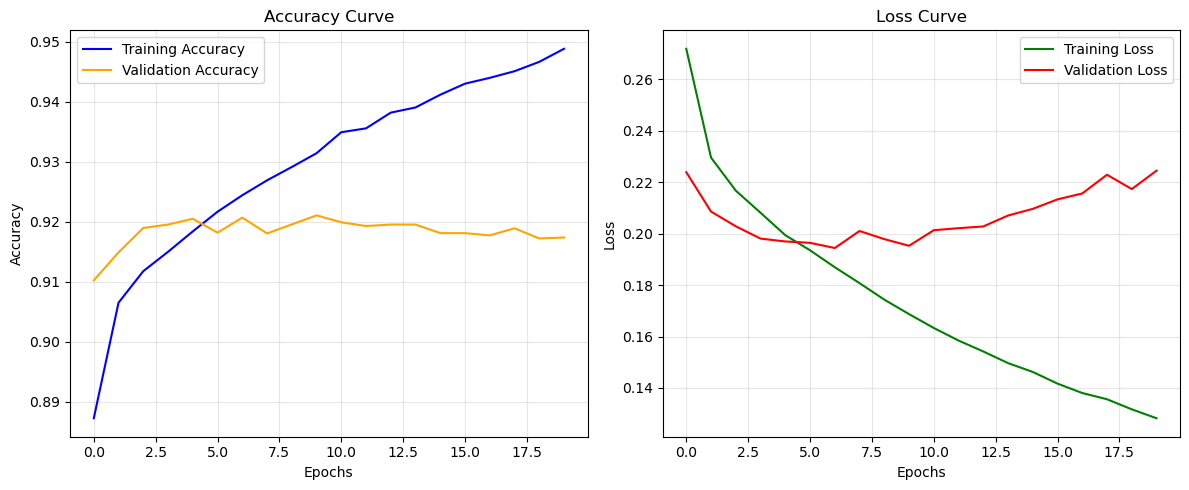

In [7]:
import matplotlib.pyplot as plt

# Plot Accuracy Curve
plt.figure(figsize=(12, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='green')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
